In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xgboost as xgb

# Time series cross validation
# Using sklearn's TimeSeriesSplit to create cross validation folds that respect the temporal order of the data. This allows us to evaluate our model's performance on unseen data while still using all available data for training and testing.
from sklearn.model_selection import TimeSeriesSplit


In [2]:
# Load in all CSV files into a list of DataFrames
df_list = [pd.read_csv(f'../data/entsoe_power_stats/monthly_hourly_load_values_{year}.csv', delimiter=r'[\t;]') for year in range(2019, 2025)]
#df = pd.read_csv('data/monthly_hourly_load_values_2019.csv', delimiter='\t', parse_dates=['DateUTC'])

/var/folders/40/_dzhm_n16gn9bfdpc_8tcpf00000gp/T/ipykernel_60694/2441596632.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_list = [pd.read_csv(f'../data/entsoe_power_stats/monthly_hourly_load_values_{year}.csv', delimiter=r'[\t;]') for year in range(2019, 2025)]
/var/folders/40/_dzhm_n16gn9bfdpc_8tcpf00000gp/T/ipykernel_60694/2441596632.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_list = [pd.read_csv(f'../data/entsoe_power_stats/monthly_hourly_load_values_{year}.csv', delimiter=r'[\t;]') for year in range(2019, 2025)]
/var/folders/40/_dzhm_n16gn9bfdpc_8tcpf00000gp/T/ipykernel_60694/244

In [3]:
# Double check everything looks correct by printing the head of each DataFrame
for df in df_list:
    print('______')
    print(df.head())

______
                  MeasureItem           DateUTC   DateShort TimeFrom TimeTo  \
0  Monthly Hourly Load Values  01-01-2019 00:00  01-01-2019    00:00  01:00   
1  Monthly Hourly Load Values  01-01-2019 01:00  01-01-2019    01:00  02:00   
2  Monthly Hourly Load Values  01-01-2019 02:00  01-01-2019    02:00  03:00   
3  Monthly Hourly Load Values  01-01-2019 03:00  01-01-2019    03:00  04:00   
4  Monthly Hourly Load Values  01-01-2019 04:00  01-01-2019    04:00  05:00   

  CountryCode  Cov_ratio   Value  Value_ScaleTo100           CreateDate  \
0          AT        100  5852.5            5852.5  29-05-2024 11:37:27   
1          AT        100  5619.2            5619.2  29-05-2024 11:37:27   
2          AT        100  5323.9            5323.9  29-05-2024 11:37:27   
3          AT        100  5273.3            5273.3  29-05-2024 11:37:27   
4          AT        100  5439.0            5439.0  29-05-2024 11:37:27   

            UpdateDate  
0  29-05-2024 11:37:27  
1  29-05-2024 11:

In [4]:
# Create one single DataFrame by concatenating the list of DataFrames
df = pd.concat(df_list)

# Subset to just the Netherlands
df_nl = df.loc[df['CountryCode'] == 'NL']

# Check that cov_ratio is always 100
print(df_nl['Cov_ratio'].unique())

[100]


In [5]:
def make_index(df):
    """ Function to make a datetime index from the DateUTC column, which has a changing format across files. """
    df = df.copy()

    # Handle the date column with changing format
    df['DateUTC'] = df.DateUTC.replace('/', '-', regex=True)
    
    # Set index to DateUTC and convert to datetime
    df.set_index('DateUTC', inplace=True)
    df.index = pd.to_datetime(df.index, format='%d-%m-%Y %H:%M')
    return df

df_nl = make_index(df_nl)

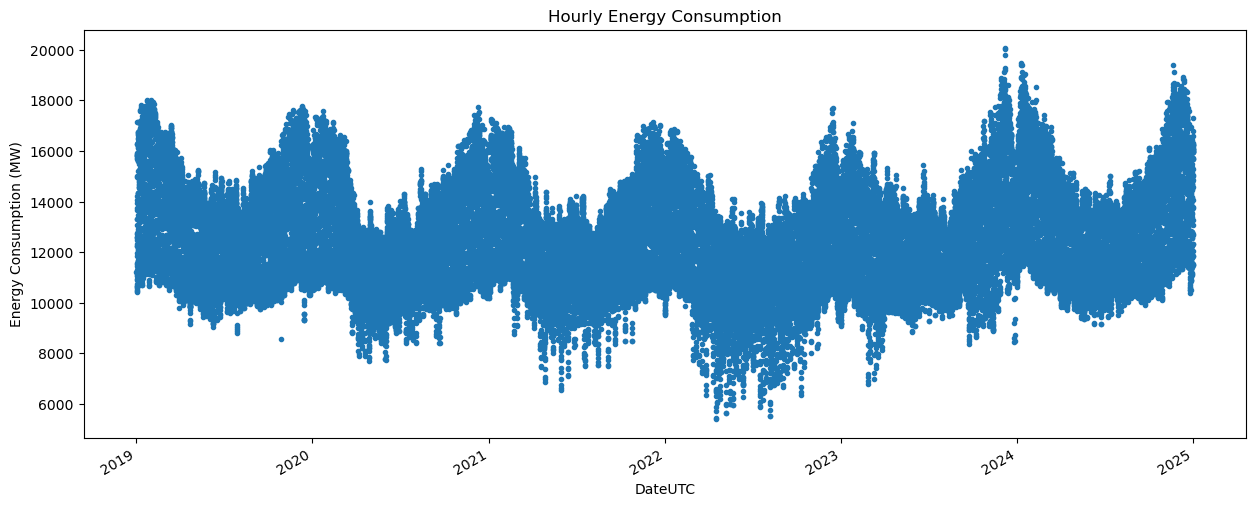

In [6]:
# Plot the hourly energy consumption
df_nl['Value'].plot(style='.', figsize=(15, 6), title='Hourly Energy Consumption')
plt.ylabel('Energy Consumption (MW)')
plt.show()

In [7]:
# Let's add some features to this
def create_features(df):
    """ Creates time series features from datetime index
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.day_of_week
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.day_of_year

    return df
df_nl = create_features(df_nl)

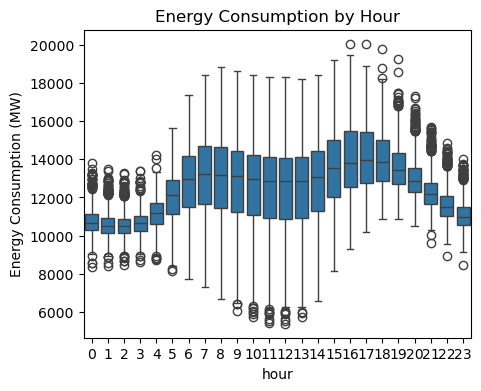

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=df_nl, x='hour', y='Value', ax=ax)
plt.title('Energy Consumption by Hour')
plt.ylabel('Energy Consumption (MW)')
plt.show()

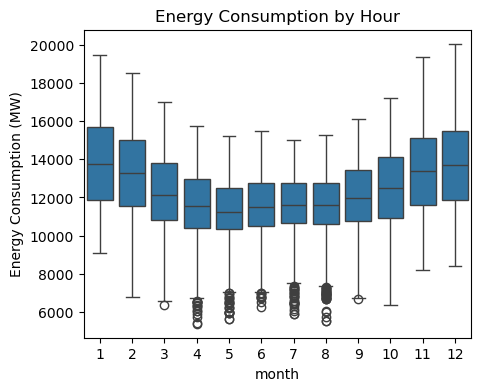

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=df_nl, x='month', y='Value', ax=ax)
plt.title('Energy Consumption by Hour')
plt.ylabel('Energy Consumption (MW)')
plt.show()

In [10]:
# Let's build a simple model with these features to see how well we can predict the energy consumption
# Later, we will add more features to see if we can improve our model performance

In [11]:
# Create model
from sklearn.metrics import mean_squared_error

In [12]:
tss = TimeSeriesSplit(n_splits=5,
                      test_size = 24*364*1,
                      gap=24)
df_nl = df_nl.sort_index() # Needs to be ordered


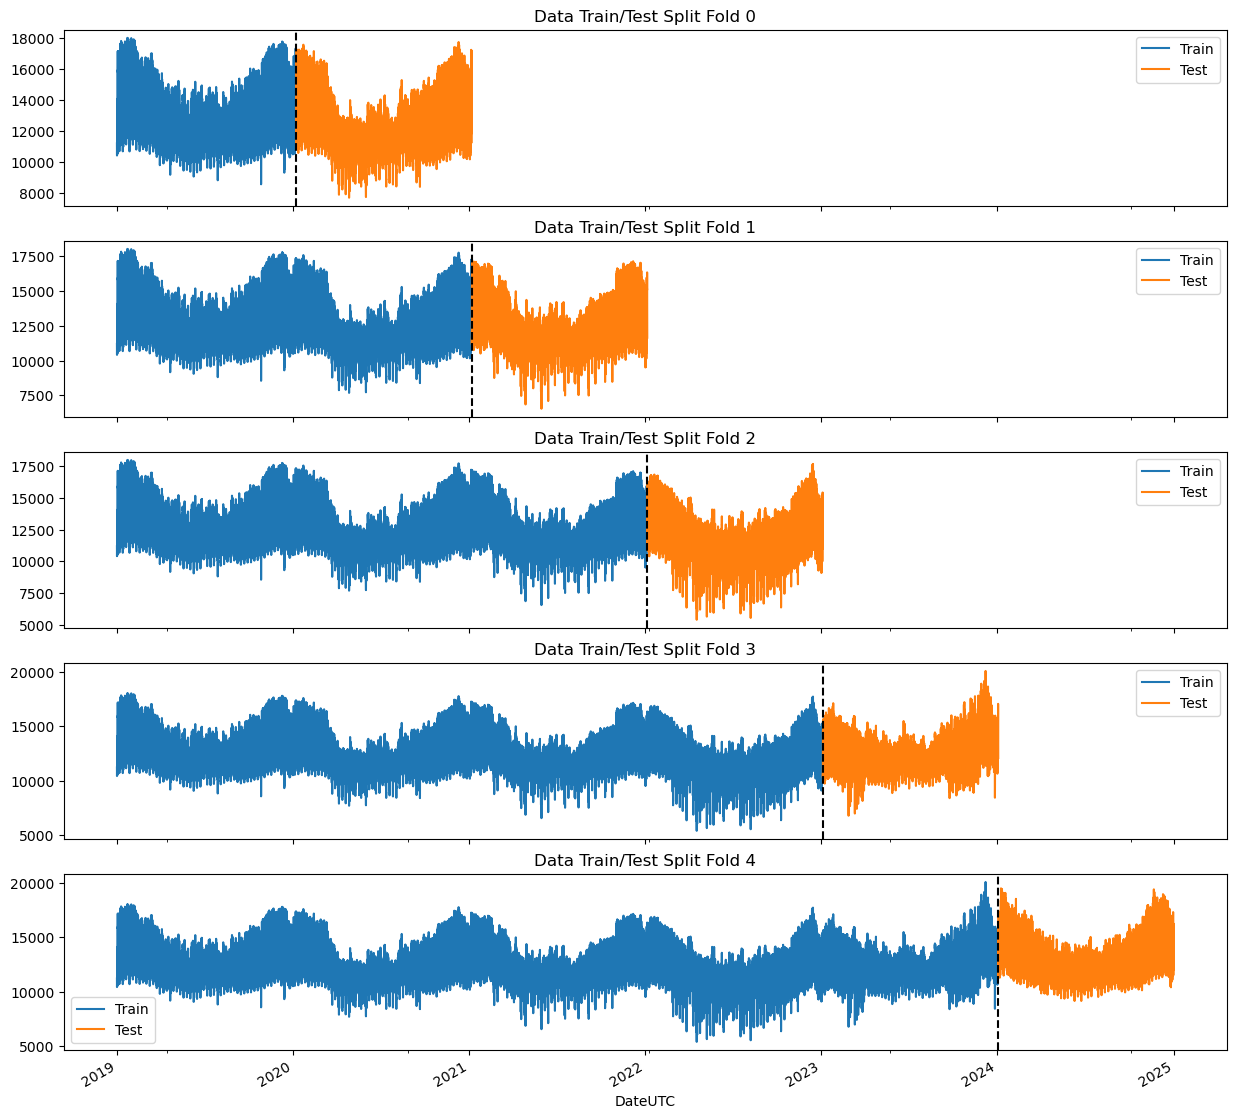

In [13]:
fig, axs = plt.subplots(5,1, figsize=(15,15),
                       sharex=True)
fold = 0
for train_idx, val_idx in tss.split(df_nl):
    train = df_nl.iloc[train_idx]
    test = df_nl.iloc[val_idx]
    train['Value'].plot(ax=axs[fold],
                          label='Train',
                          title=f'Data Train/Test Split Fold {fold}')
    test['Value'].plot(ax=axs[fold],
                            label='Test')
    axs[fold].axvline(x=test.index[0], color='k', ls='--')
    axs[fold].legend()
    fold+=1

In [14]:
df_nl.drop(columns=['MeasureItem', 'DateShort', 'TimeFrom', 'TimeTo', 'Cov_ratio', 'CountryCode', 'CreateDate', 'UpdateDate', 'Value_ScaleTo100'], inplace=True)

In [15]:
df_nl.head()

,Value,hour,dayofweek,quarter,month,year,dayofyear
DateUTC,,,,,,,
2019-01-01 00:00:00,11193.6350,0,1,1,1,2019,1
2019-01-01 01:00:00,10933.3600,1,1,1,1,2019,1
2019-01-01 02:00:00,10666.5800,2,1,1,1,2019,1
2019-01-01 03:00:00,10413.3575,3,1,1,1,2019,1
2019-01-01 04:00:00,10440.7925,4,1,1,1,2019,1


In [16]:
# List of Features
TARGET = 'Value'
FEATURES = list(df_nl.drop(columns=TARGET).columns)


In [17]:
FEATURES

['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear']

--- New Fold 0 ---
[0]	validation_0-rmse:1912.53879	validation_1-rmse:2008.31268
[100]	validation_0-rmse:912.95812	validation_1-rmse:1254.91199
[200]	validation_0-rmse:609.92639	validation_1-rmse:1120.85746
[300]	validation_0-rmse:499.87127	validation_1-rmse:1094.27787
[400]	validation_0-rmse:438.98387	validation_1-rmse:1088.01726
[500]	validation_0-rmse:396.18645	validation_1-rmse:1085.58596
[513]	validation_0-rmse:391.57215	validation_1-rmse:1085.95152


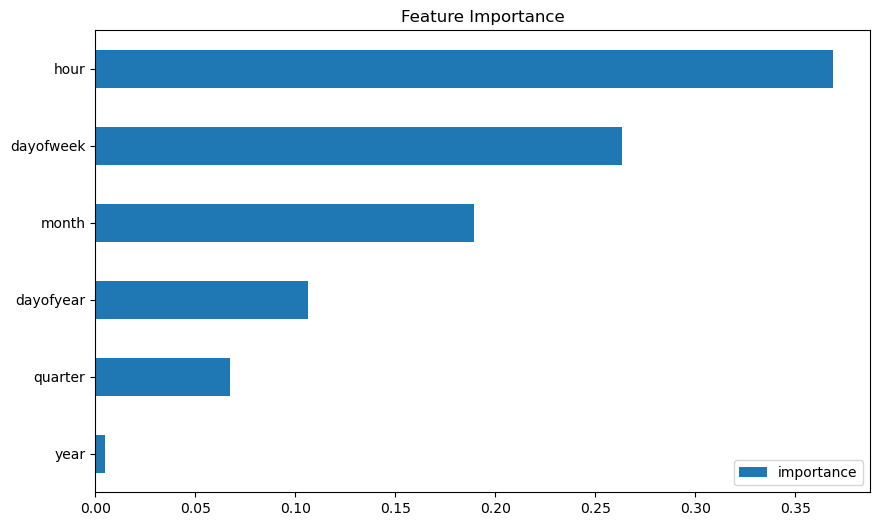

/var/folders/40/_dzhm_n16gn9bfdpc_8tcpf00000gp/T/ipykernel_60694/2405507024.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = predictions


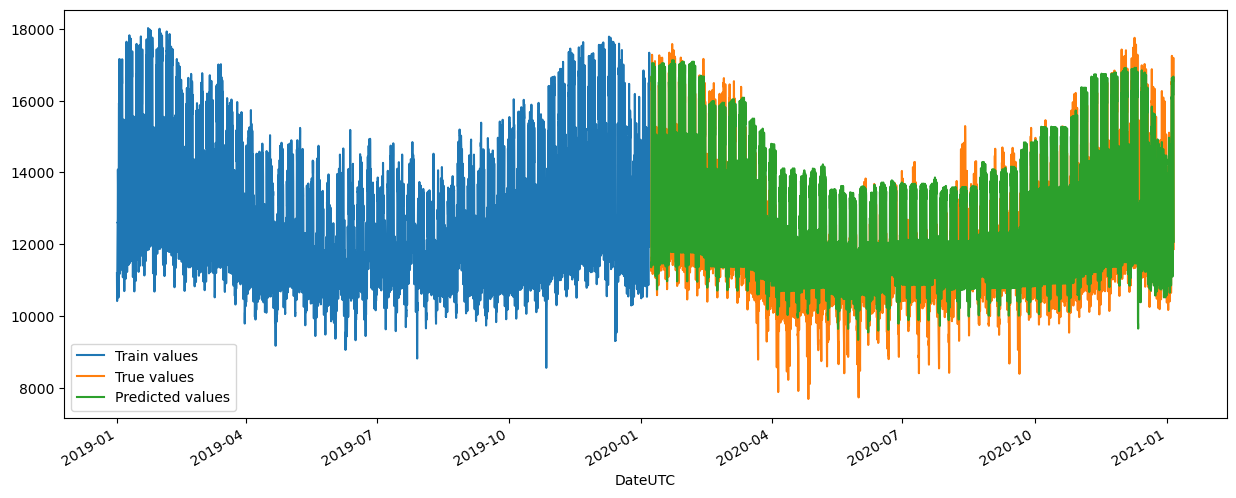

/var/folders/40/_dzhm_n16gn9bfdpc_8tcpf00000gp/T/ipykernel_60694/2405507024.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['error'] = error


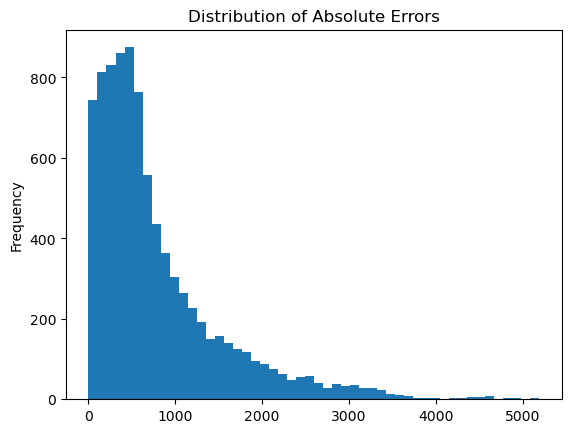

--- New Fold 1 ---
[0]	validation_0-rmse:1928.50266	validation_1-rmse:1899.54034
[100]	validation_0-rmse:992.04308	validation_1-rmse:1096.71078
[200]	validation_0-rmse:700.38537	validation_1-rmse:910.72985
[300]	validation_0-rmse:568.03229	validation_1-rmse:832.39880
[400]	validation_0-rmse:500.88540	validation_1-rmse:811.11563
[500]	validation_0-rmse:458.42282	validation_1-rmse:804.80903
[546]	validation_0-rmse:444.06593	validation_1-rmse:805.30478


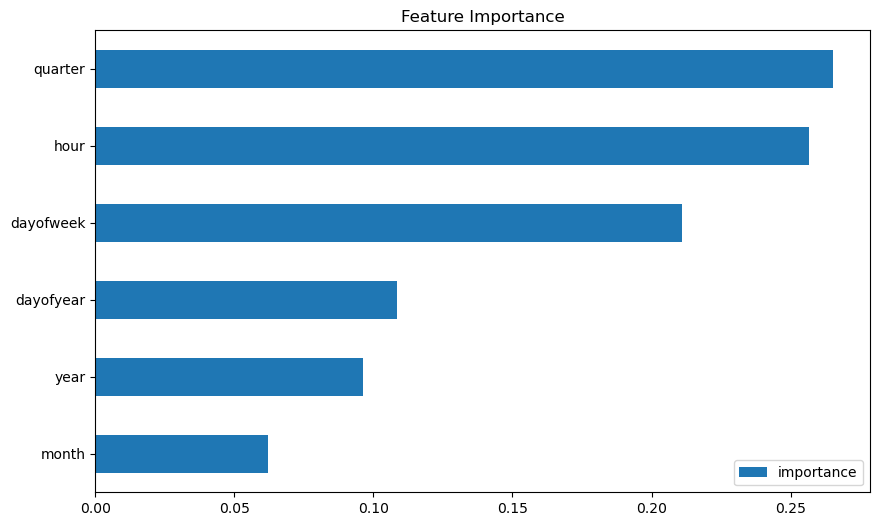

/var/folders/40/_dzhm_n16gn9bfdpc_8tcpf00000gp/T/ipykernel_60694/2405507024.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = predictions


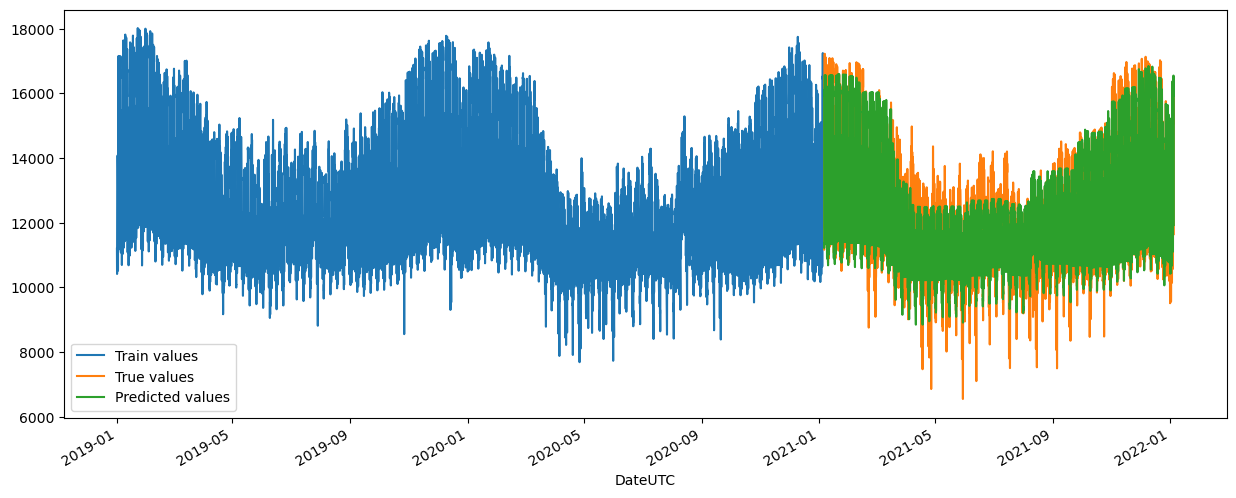

/var/folders/40/_dzhm_n16gn9bfdpc_8tcpf00000gp/T/ipykernel_60694/2405507024.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['error'] = error


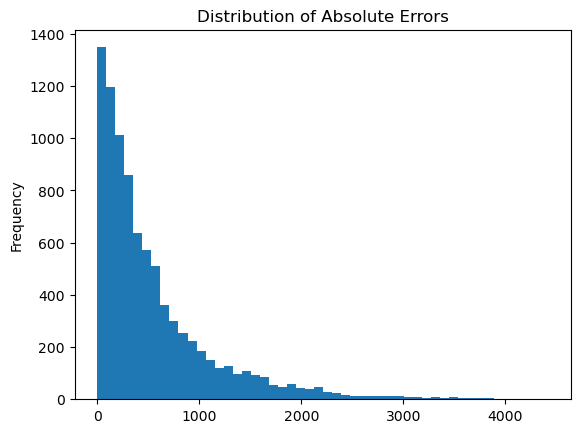

--- New Fold 2 ---
[0]	validation_0-rmse:1912.56258	validation_1-rmse:2211.49018
[100]	validation_0-rmse:1036.57607	validation_1-rmse:1596.90395
[200]	validation_0-rmse:759.62854	validation_1-rmse:1412.85582
[300]	validation_0-rmse:636.78809	validation_1-rmse:1294.67199
[400]	validation_0-rmse:576.72572	validation_1-rmse:1237.50379
[500]	validation_0-rmse:538.50542	validation_1-rmse:1211.60502
[600]	validation_0-rmse:512.02195	validation_1-rmse:1196.66909
[700]	validation_0-rmse:495.84382	validation_1-rmse:1193.03770
[800]	validation_0-rmse:483.93829	validation_1-rmse:1189.40943
[900]	validation_0-rmse:473.25211	validation_1-rmse:1187.32531
[999]	validation_0-rmse:463.09334	validation_1-rmse:1187.25056


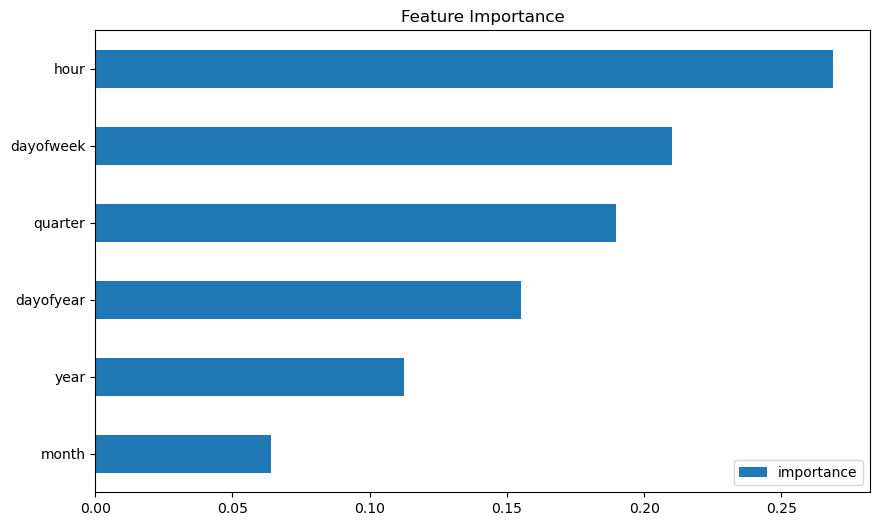

/var/folders/40/_dzhm_n16gn9bfdpc_8tcpf00000gp/T/ipykernel_60694/2405507024.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = predictions


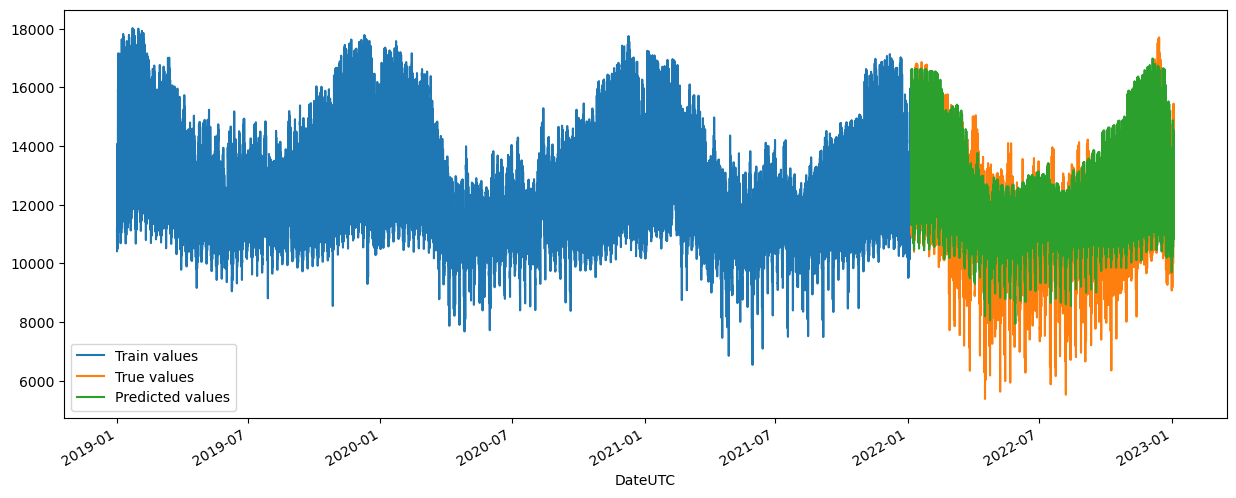

/var/folders/40/_dzhm_n16gn9bfdpc_8tcpf00000gp/T/ipykernel_60694/2405507024.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['error'] = error


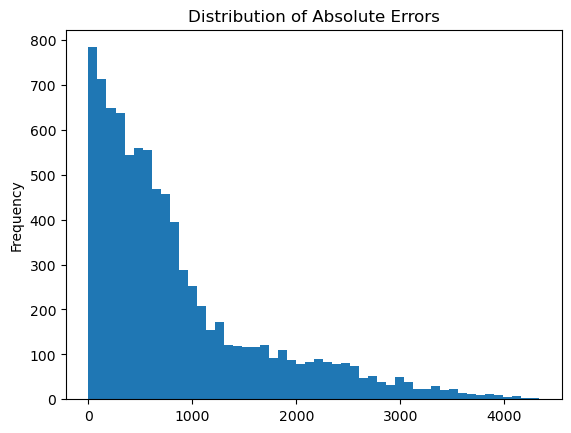

--- New Fold 3 ---
[0]	validation_0-rmse:1975.00171	validation_1-rmse:1869.11453
[100]	validation_0-rmse:1129.18816	validation_1-rmse:1489.89818
[144]	validation_0-rmse:960.35074	validation_1-rmse:1509.07004


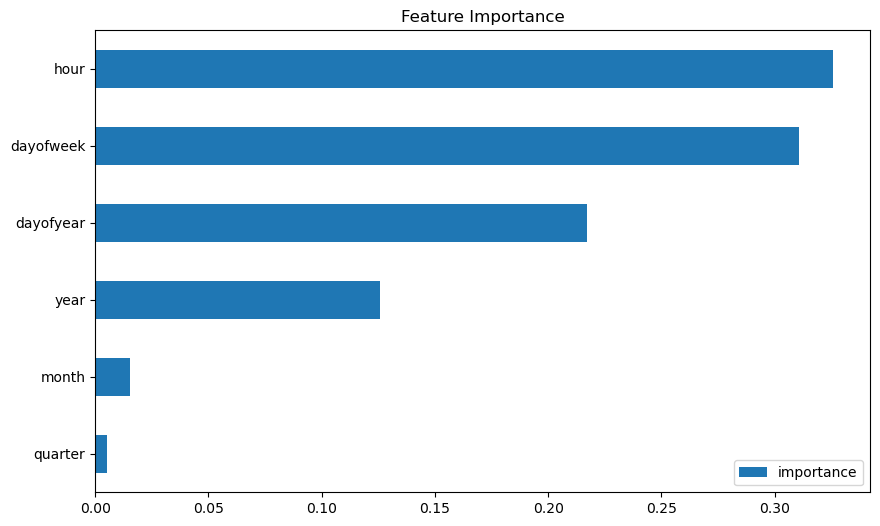

/var/folders/40/_dzhm_n16gn9bfdpc_8tcpf00000gp/T/ipykernel_60694/2405507024.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = predictions


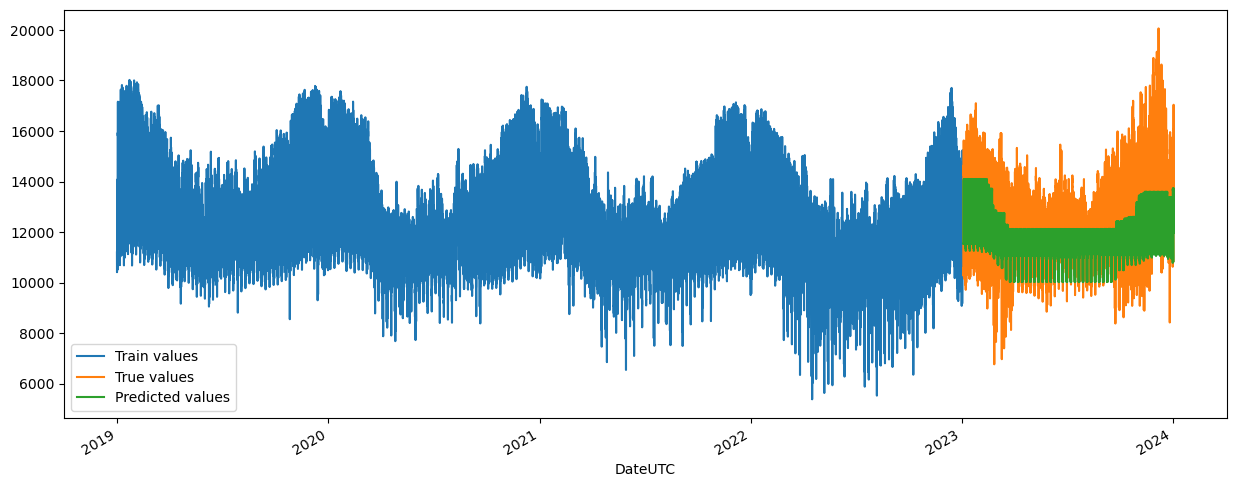

/var/folders/40/_dzhm_n16gn9bfdpc_8tcpf00000gp/T/ipykernel_60694/2405507024.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['error'] = error


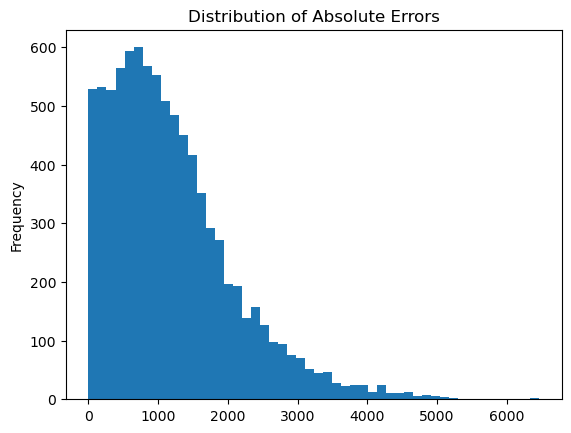

--- New Fold 4 ---
[0]	validation_0-rmse:1953.27760	validation_1-rmse:2116.58327
[100]	validation_0-rmse:1188.50621	validation_1-rmse:1449.53244
[200]	validation_0-rmse:883.36193	validation_1-rmse:1198.44213
[300]	validation_0-rmse:735.31643	validation_1-rmse:1131.87965
[400]	validation_0-rmse:666.48069	validation_1-rmse:1115.48300
[463]	validation_0-rmse:639.62346	validation_1-rmse:1117.22559


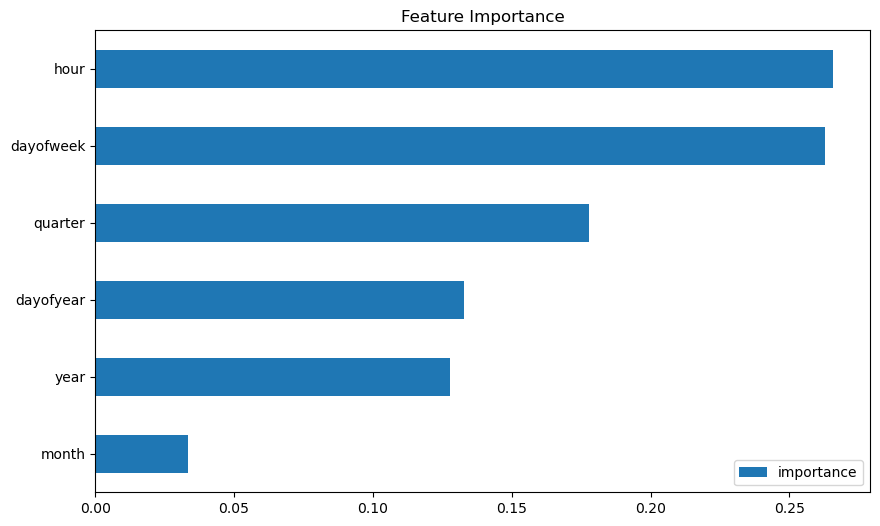

/var/folders/40/_dzhm_n16gn9bfdpc_8tcpf00000gp/T/ipykernel_60694/2405507024.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = predictions


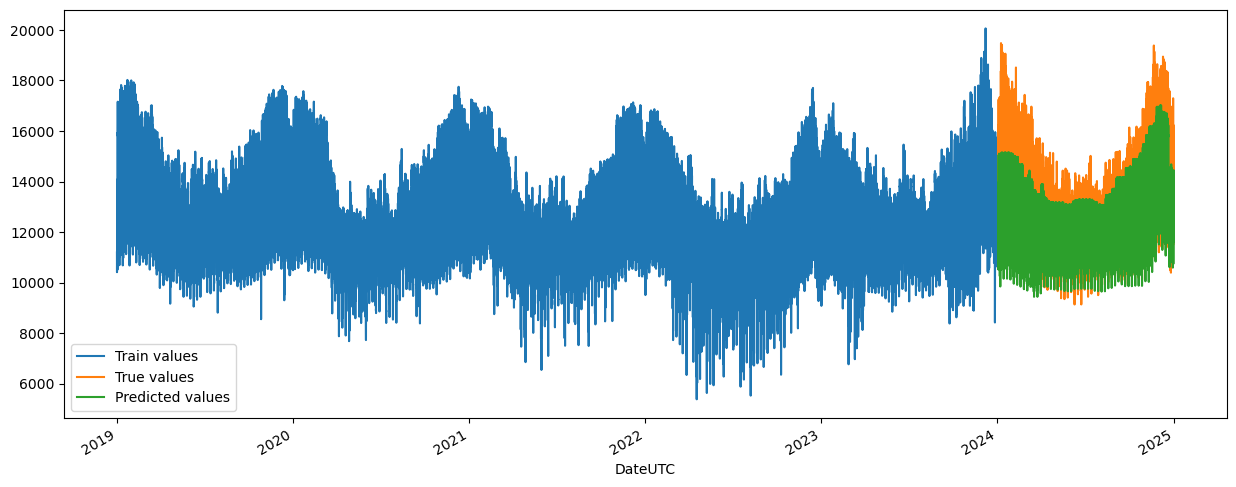

/var/folders/40/_dzhm_n16gn9bfdpc_8tcpf00000gp/T/ipykernel_60694/2405507024.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['error'] = error


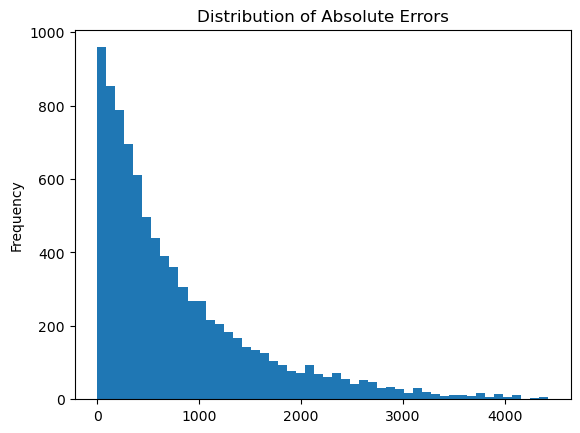

In [18]:
scores = {}
# Let's build the model and evaluate it on the test set for each fold
for fold, (train_idx, val_idx) in enumerate(tss.split(df_nl)):
    print(f'--- New Fold {fold} ---')
    train = df_nl.iloc[train_idx]
    X_train = train[FEATURES]
    y_train = train[TARGET]

    test = df_nl.iloc[val_idx]
    X_test = test[FEATURES]
    y_test = test[TARGET]

    # Fit a model
    reg = xgb.XGBRegressor(objective='reg:squarederror',
                           n_estimators=1000,
                           early_stopping_rounds=50,
                           learning_rate=0.01)
    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)
    
    # Plot the importance of each feature
    fi = pd.DataFrame(reg.feature_importances_, index=FEATURES, columns=['importance'])
    fi.sort_values('importance').plot(kind='barh', figsize=(10, 6), title='Feature Importance')
    plt.show()

    predictions = reg.predict(X_test)
    test['prediction'] = predictions

    # Plot the predictions vs the true values
    fig, ax = plt.subplots(figsize=(15, 6))
    train[TARGET].plot(ax=ax, label='Train values')
    test[TARGET].plot(ax=ax, label='True values')
    test['prediction'].plot(ax=ax, label='Predicted values')
    ax.legend()
    plt.show()

    # Measure the error
    error = np.abs(test[TARGET] - test['prediction'])
    test['error'] = error
    test['error'].plot(kind='hist', bins=50, title='Distribution of Absolute Errors')
    plt.show()
    
    score = np.sqrt(mean_squared_error(test[TARGET], test['prediction'])) # RMSE
    scores[fold] = score
